# Assignment 

## 1. What is a Statistical Distribution?

A **statistical distribution** describes how values of a variable are spread or distributed across possible outcomes. It shows:

* Possible values a variable can take
* Frequency or probability of each value

In simple words:

> A statistical distribution tells **how data behaves**.

It helps in:

* Understanding patterns
* Predicting outcomes
* Statistical modeling

---

## 2. Difference Between Discrete and Continuous Distribution

| Feature     | Discrete Distribution            | Continuous Distribution      |
| ----------- | -------------------------------- | ---------------------------- |
| Definition  | Deals with countable values      | Deals with measurable values |
| Data Type   | Integers (finite/countable)      | Infinite real values         |
| Example     | Number of students               | Height, weight, time         |
| Probability | Exact probability for each value | Probability over intervals   |
| Graph Shape | Bar graph                        | Smooth curve                 |

**Key Idea:**

> Discrete → countable \
> Continuous → measurable

---

## 3. What Does a Q-Q Plot Indicate?

A **Q-Q (Quantile–Quantile) plot** compares two probability distributions by plotting their quantiles.

It is mainly used to check:

* Whether a dataset follows a theoretical distribution (often normal)

### Interpretation:

* Points lie on straight line → data follows distribution
* Deviations → non-normal behavior
* Curves → skewness

In simple terms:

> A Q-Q plot checks **data normality**.

---

## 4. Bernoulli Distribution — Definition

A **Bernoulli distribution** models an experiment with only **two outcomes**:

* Success (1)
* Failure (0)

If probability of success = **p**, then:

```
P(X = x) = p^x (1 − p)^(1 − x),   where x = 0 or 1
```

Examples:

* Coin toss (Head/Tail)
* Pass/Fail

---

## 5. Binomial Distribution — Definition

A **Binomial distribution** represents the number of successes in a fixed number of independent Bernoulli trials.

Formula:

```
P(X = k) = C(n,k) p^k (1 − p)^(n − k)
```

Where:

* n = number of trials
* k = number of successes
* p = probability of success

Example:

* Number of heads in 5 coin tosses

---

## 6. Assumptions of Binomial Distribution

A binomial experiment must satisfy:

✔ Fixed number of trials (n) \
✔ Only two outcomes (success/failure) \
✔ Trials are independent \
✔ Constant probability of success (p) \
✔ Same conditions for each trial

---

# A website has conversion probability = 0.25.

### **Tasks:**

1. Model one visitor using Bernoulli distribution.
2. Model 15 visitors using Binomial distribution.
3. Plot binomial probability distribution.
4. Find probability exactly 5 users convert.
5. Simulate 1000 experiments and compare empirical vs theoretical probability.
6. Use Q-Q plot to check sampling distribution of sample means.

In [1]:
import numpy as np 
import math 
import matplotlib.pyplot as plt 
import scipy as stats  

p = 0.25 
n = 15
k = 5

print("Bernoulli Model (Single Visitor)")
print(f"P(success) = {p}")
print(f"P(failure) = {1 - p} \n")

Bernoulli Model (Single Visitor)
P(success) = 0.25
P(failure) = 0.75 



In [2]:
print("=== Binomial Model (15 Visitors) ===")
def binomial_pmf(n, k, p):
    return math.comb(n, k) * (p**k) * ((1-p)**(n-k))

prob_5 = binomial_pmf(n, k, p)
print(f"Probability exactly 5 users convert = {prob_5 :.4f}")

=== Binomial Model (15 Visitors) ===
Probability exactly 5 users convert = 0.1651


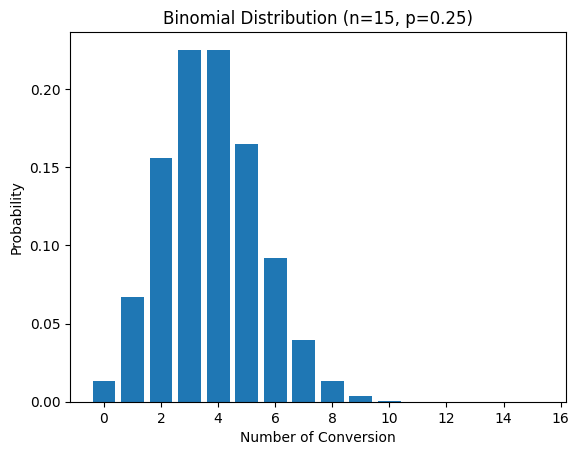

In [3]:
x = np.arange(0, n+1)
y = [binomial_pmf(n, i, p) for i in x ]

plt.bar(x, y)
plt.title("Binomial Distribution (n=15, p=0.25)")
plt.xlabel("Number of Conversion")
plt.ylabel("Probability")
plt.show()


In [4]:
experiments = 1000
sim_data = np.random.binomial(n, p, size=experiments)

empirical_prob_5 = np.mean(sim_data == 5)
print("=== Simulation Results ===")
print(f"Empirical probability (k=5) = {empirical_prob_5:.6f}")
print(f"Theoretical probability (k=5) = {prob_5:.6f}\n")


=== Simulation Results ===
Empirical probability (k=5) = 0.164000
Theoretical probability (k=5) = 0.165146



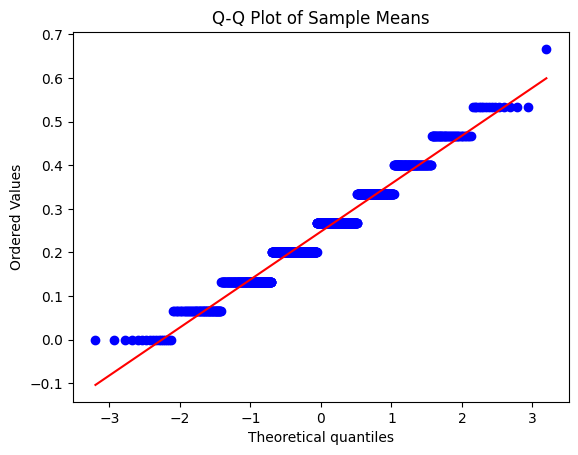

In [5]:
from scipy import stats
sample_size = 15
means = []
for _ in range(experiments):
    sample = np.random.binomial(1, p, size=sample_size)
    means.append(np.mean(sample))

means = np.array(means)

plt.figure()
stats.probplot(means, plot=plt)
plt.title("Q-Q Plot of Sample Means")
plt.show()